In [1]:
!pip install shap

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    r'D:\Data_D\TMU\MRP\1.0.Dataset\Crime_Socio_Economic_Weather_Mobility.csv'
)

# Basic information
print("Dataset Shape:")
print(df.shape)

print("\nTarget Distribution:")
print(df['Arrest'].value_counts())

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape:
(7970658, 36)

Target Distribution:
Arrest
0    5913853
1    2056805
Name: count, dtype: int64

Columns:
['Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'community_area', 'FBI Code', 'year', 'Latitude', 'Longitude', 'month', 'day_of_week', 'hour', 'is_weekend', 'community_name', 'per_capita_income', 'unemployment_rate', 'no_highschool_pct', 'date', 'TMAX', 'TMIN', 'PRCP', 'SNOW', 'AWND', 'temp_avg', 'is_rain', 'is_snow', 'temp_category', 'high_wind', 'day_type', 'bus', 'rail_boardings', 'total_rides', 'day']


In [3]:
# Missing values check

missing = df.isnull().sum()

missing = missing[missing > 0]

print("Missing Values:")
print(missing.sort_values(ascending=False))

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Missing Values:
Series([], dtype: int64)

Total Missing Values:
0


In [4]:
# Features and Target

X = df.drop('Arrest', axis=1)
y = df['Arrest']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nFeature Types:")
print(X.dtypes.value_counts())

X Shape: (7970658, 35)
y Shape: (7970658,)

Feature Types:
int64      24
float64    10
object      1
Name: count, dtype: int64


In [5]:
# Find categorical columns

categorical_cols = X.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['community_name']


In [6]:
print("Unique Community Names:")
print(df['community_name'].nunique())

print("\nSample Values:")
print(df['community_name'].unique()[:10])

Unique Community Names:
80

Sample Values:
['roseland' 'west pullman' 'jefferson park' 'new city' 'bridgeport'
 'ashburn' 'west ridge' 'south shore' 'hyde park' 'belmont cragin']


In [7]:
# Drop target and community_name

X = df.drop(columns=['Arrest', 'community_name'])

y = df['Arrest']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nRemaining Columns:")
print(len(X.columns))

X Shape: (7970658, 34)
y Shape: (7970658,)

Remaining Columns:
34


In [8]:
from sklearn.model_selection import train_test_split

# Take a random sample of 200,000 rows
sample_df = df.sample(
    n=200000,
    random_state=42
)

X_sample = sample_df.drop(
    columns=['Arrest', 'community_name']
)

y_sample = sample_df['Arrest']

print("Sample Shape:", X_sample.shape)

print("\nTarget Distribution:")
print(y_sample.value_counts(normalize=True) * 100)

Sample Shape: (200000, 34)

Target Distribution:
Arrest
0    74.129
1    25.871
Name: proportion, dtype: float64


In [9]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_sample, y_sample)

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Show Top 20
print(importance_df.head(20))

                 Feature  Importance
7               FBI Code    0.249509
1            Description    0.117719
0           Primary Type    0.096930
2   Location Description    0.042522
18                  date    0.033479
10             Longitude    0.030411
9               Latitude    0.030273
30                   bus    0.026359
31        rail_boardings    0.026023
32           total_rides    0.025666
13                  hour    0.024947
23                  AWND    0.024310
4                   Beat    0.023140
24              temp_avg    0.022426
19                  TMAX    0.021652
33                   day    0.021629
20                  TMIN    0.021547
8                   year    0.018638
15     per_capita_income    0.018344
17     no_highschool_pct    0.016948


In [10]:
pd.set_option('display.max_rows', None)

print(importance_df)

                 Feature  Importance
7               FBI Code    0.249509
1            Description    0.117719
0           Primary Type    0.096930
2   Location Description    0.042522
18                  date    0.033479
10             Longitude    0.030411
9               Latitude    0.030273
30                   bus    0.026359
31        rail_boardings    0.026023
32           total_rides    0.025666
13                  hour    0.024947
23                  AWND    0.024310
4                   Beat    0.023140
24              temp_avg    0.022426
19                  TMAX    0.021652
33                   day    0.021629
20                  TMIN    0.021547
8                   year    0.018638
15     per_capita_income    0.018344
17     no_highschool_pct    0.016948
16     unemployment_rate    0.016750
6         community_area    0.014351
11                 month    0.014168
3               Domestic    0.012044
21                  PRCP    0.011405
12           day_of_week    0.010887
5

In [11]:
importance_df.to_csv(
    "Feature_Importance.csv",
    index=False
)

print(importance_df)

                 Feature  Importance
7               FBI Code    0.249509
1            Description    0.117719
0           Primary Type    0.096930
2   Location Description    0.042522
18                  date    0.033479
10             Longitude    0.030411
9               Latitude    0.030273
30                   bus    0.026359
31        rail_boardings    0.026023
32           total_rides    0.025666
13                  hour    0.024947
23                  AWND    0.024310
4                   Beat    0.023140
24              temp_avg    0.022426
19                  TMAX    0.021652
33                   day    0.021629
20                  TMIN    0.021547
8                   year    0.018638
15     per_capita_income    0.018344
17     no_highschool_pct    0.016948
16     unemployment_rate    0.016750
6         community_area    0.014351
11                 month    0.014168
3               Domestic    0.012044
21                  PRCP    0.011405
12           day_of_week    0.010887
5

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='f1'
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
})

perm_df = perm_df.sort_values(
    by='Importance',
    ascending=False
)

print(perm_df)

                 Feature  Importance
7               FBI Code    0.419258
1            Description    0.183019
0           Primary Type    0.166892
2   Location Description    0.124051
18                  date    0.061228
13                  hour    0.059770
3               Domestic    0.053620
9               Latitude    0.035102
17     no_highschool_pct    0.031526
8                   year    0.030541
15     per_capita_income    0.029149
16     unemployment_rate    0.027865
10             Longitude    0.021317
4                   Beat    0.021257
31        rail_boardings    0.018850
30                   bus    0.017586
33                   day    0.015596
32           total_rides    0.015200
6         community_area    0.014212
23                  AWND    0.013652
24              temp_avg    0.010217
19                  TMAX    0.009964
11                 month    0.009108
20                  TMIN    0.008968
21                  PRCP    0.006478
5               District    0.004007
1

In [13]:
import shap

print(shap.__version__)

0.52.0


In [14]:
# Small sample for SHAP

X_shap = X_sample.sample(
    n=100,
    random_state=42
)

print(X_shap.shape)

(100, 34)


In [15]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated.")

SHAP values calculated.


In [16]:
type(shap_values)

numpy.ndarray

In [17]:
if isinstance(shap_values, list):
    print(len(shap_values))
    print(shap_values[1].shape)
else:
    print(shap_values.shape)

(100, 34, 2)


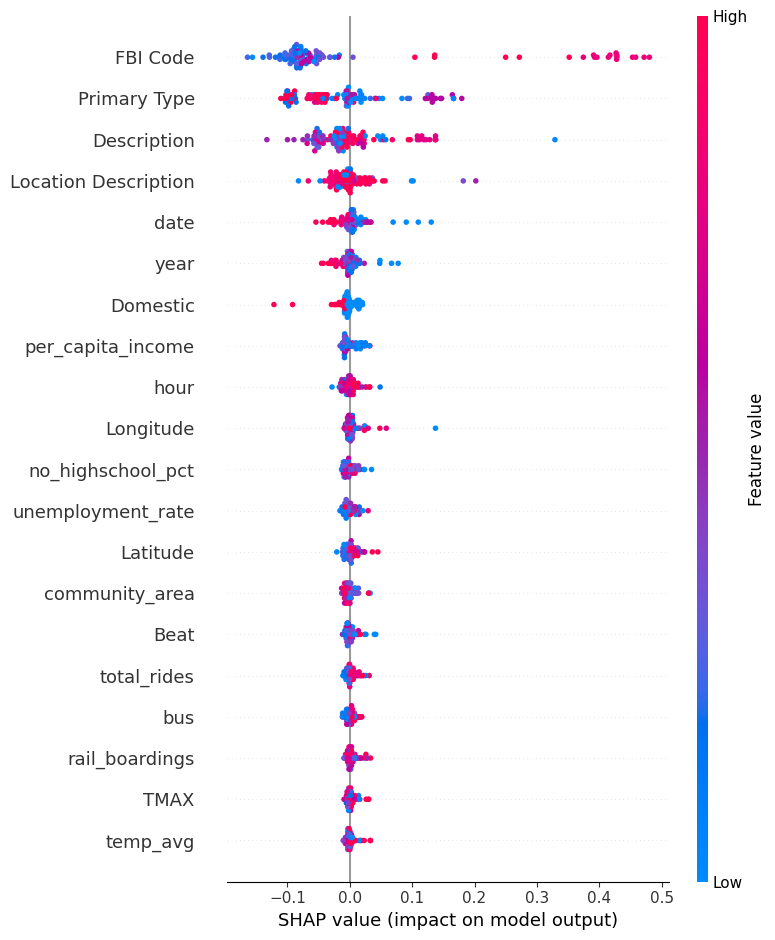

In [18]:
import numpy as np

# For SHAP 0.52+
shap.summary_plot(
    shap_values[:, :, 1],
    X_shap
)

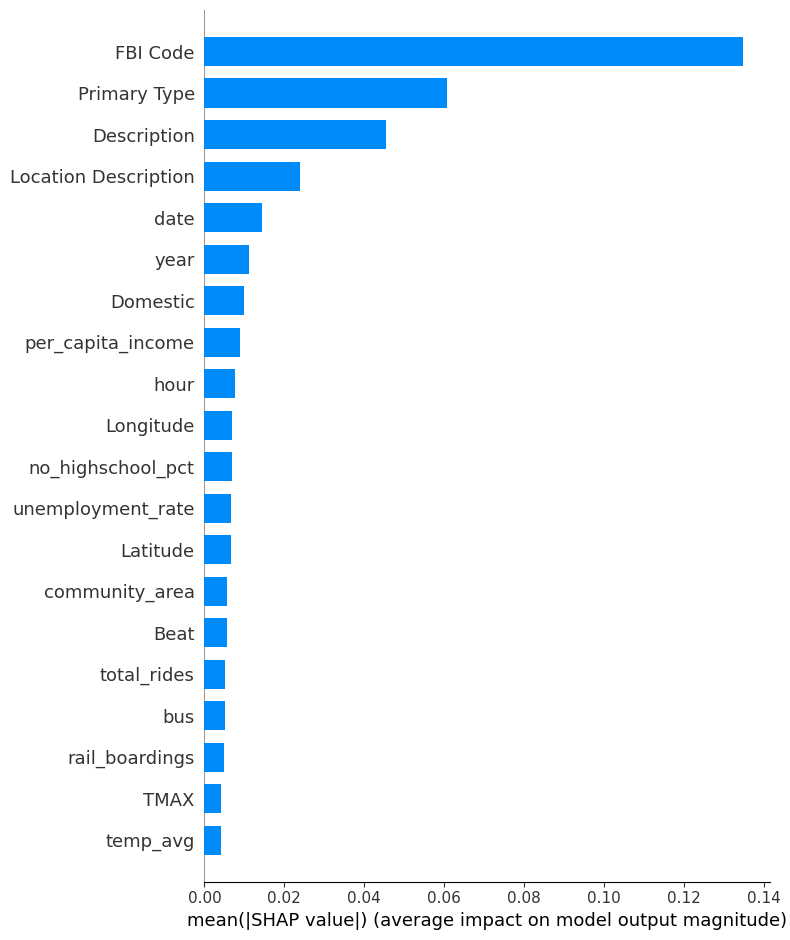

In [19]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_shap,
    plot_type="bar"
)

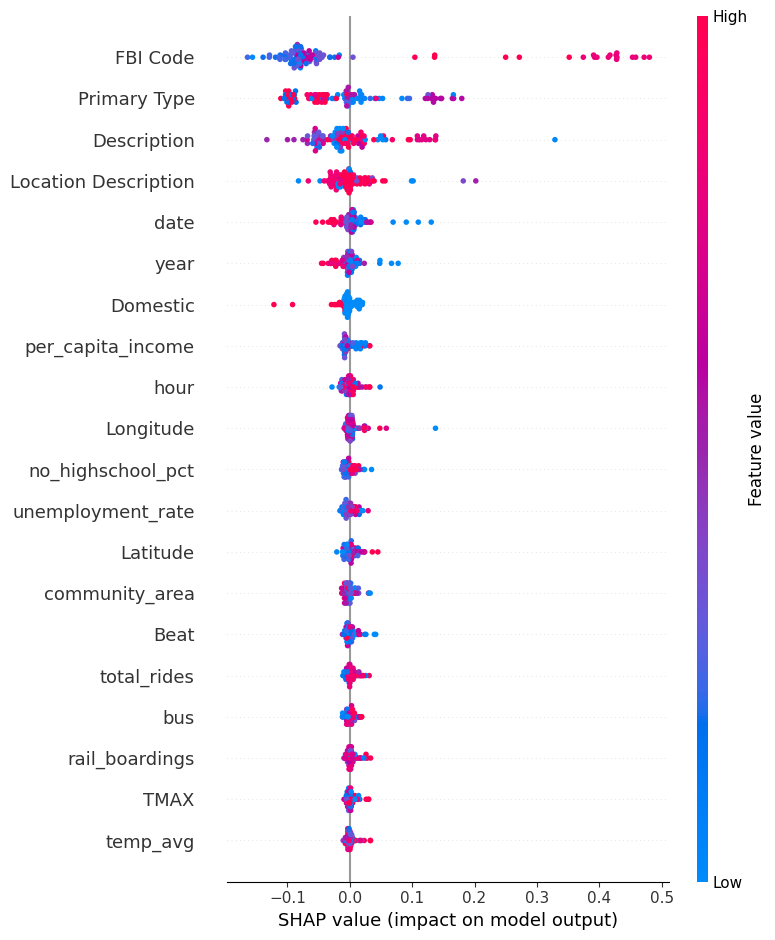

In [20]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_shap
)

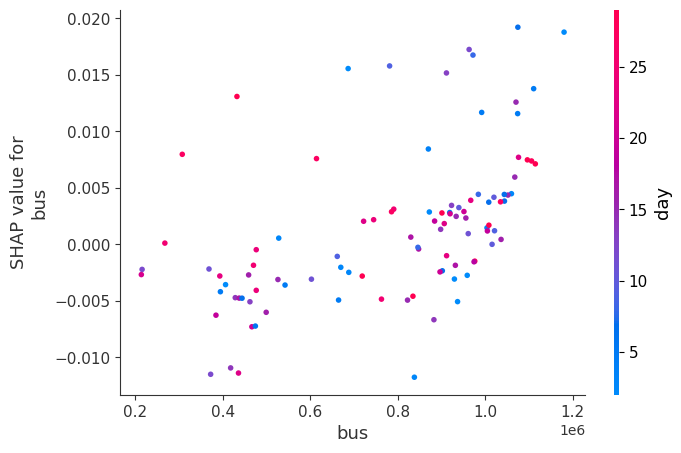

In [21]:
shap.dependence_plot(
    "bus",
    shap_values[:, :, 1],
    X_shap
)

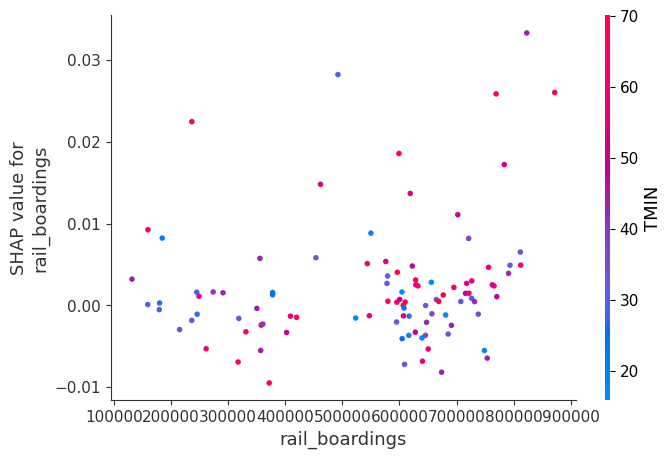

In [22]:
shap.dependence_plot(
    "rail_boardings",
    shap_values[:, :, 1],
    X_shap
)

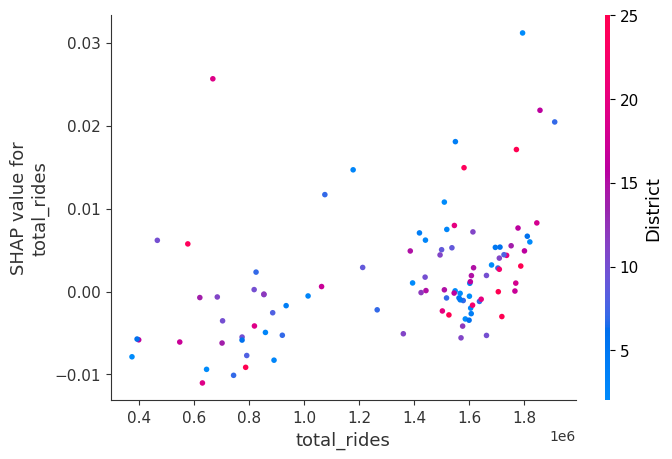

In [23]:
shap.dependence_plot(
    "total_rides",
    shap_values[:, :, 1],
    X_shap
)

In [24]:
# Target
y = df['Arrest']

# Features
X = df.drop(
    columns=[
        'Arrest',
        'community_name',  # already removed
        'is_weekend',
        'high_wind',
        'is_snow',
        'is_rain',
        'temp_category',
        'day_type',
        'SNOW'
    ]
)

print("Final Shape:", X.shape)
print("Number of Features:", len(X.columns))
print("\nFeatures:")
print(X.columns.tolist())

Final Shape: (7970658, 27)
Number of Features: 27

Features:
['Primary Type', 'Description', 'Location Description', 'Domestic', 'Beat', 'District', 'community_area', 'FBI Code', 'year', 'Latitude', 'Longitude', 'month', 'day_of_week', 'hour', 'per_capita_income', 'unemployment_rate', 'no_highschool_pct', 'date', 'TMAX', 'TMIN', 'PRCP', 'AWND', 'temp_avg', 'bus', 'rail_boardings', 'total_rides', 'day']


In [25]:
print(X.columns.tolist())

['Primary Type', 'Description', 'Location Description', 'Domestic', 'Beat', 'District', 'community_area', 'FBI Code', 'year', 'Latitude', 'Longitude', 'month', 'day_of_week', 'hour', 'per_capita_income', 'unemployment_rate', 'no_highschool_pct', 'date', 'TMAX', 'TMIN', 'PRCP', 'AWND', 'temp_avg', 'bus', 'rail_boardings', 'total_rides', 'day']
